In [2]:
%pip install pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install pyodbc pandas sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=anuj;"
    "DATABASE=db_Churn;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM prod_Churn"

df = pd.read_sql(query, conn)
df


C:\Users\anujj\AppData\Local\Temp\ipykernel_29536\965855066.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11596-KAR,Female,40,No,Karnataka,15,11,Deal 4,Yes,No,...,Bank Withdrawal,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed,Others,Others
1,11604-HAR,Female,38,Yes,Haryana,4,8,None,Yes,Yes,...,Bank Withdrawal,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed,Others,Others
2,11616-TAM,Male,26,No,Tamil Nadu,6,2,None,Yes,Yes,...,Bank Withdrawal,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed,Others,Others
3,11647-GUJ,Male,44,No,Gujarat,2,4,Deal 4,Yes,Yes,...,Bank Withdrawal,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed,Others,Others
4,11647-TAM,Male,81,No,Tamil Nadu,1,21,None,Yes,Yes,...,Bank Withdrawal,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,97189-KAR,Male,29,No,Karnataka,5,20,Deal 4,Yes,No,...,Credit Card,19.650000,451.549988,0.0,0,43.240002,494.790009,Stayed,Others,Others
6414,97191-TEL,Male,28,No,Telangana,15,17,Deal 1,Yes,No,...,Bank Withdrawal,103.150002,6895.500000,0.0,0,888.419983,7783.919922,Stayed,Others,Others
6415,97198-ASS,Male,35,Yes,Assam,10,24,None,Yes,No,...,Bank Withdrawal,80.800003,713.099976,0.0,0,183.059998,896.159973,Churned,Competitor,Competitor offered more data
6416,97212-UTT,Female,50,Yes,Uttar Pradesh,3,16,Deal 1,Yes,Yes,...,Bank Withdrawal,105.199997,7386.049805,0.0,0,3075.330078,10461.379883,Stayed,Others,Others


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   str    
 1   Gender                       6418 non-null   str    
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   str    
 4   State                        6418 non-null   str    
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   6418 non-null   str    
 8   Phone_Service                6418 non-null   str    
 9   Multiple_Lines               6418 non-null   str    
 10  Internet_Service             6418 non-null   str    
 11  Internet_Type                6418 non-null   str    
 12  Online_Security              6418 non-null   str    
 13  Online_Backup                

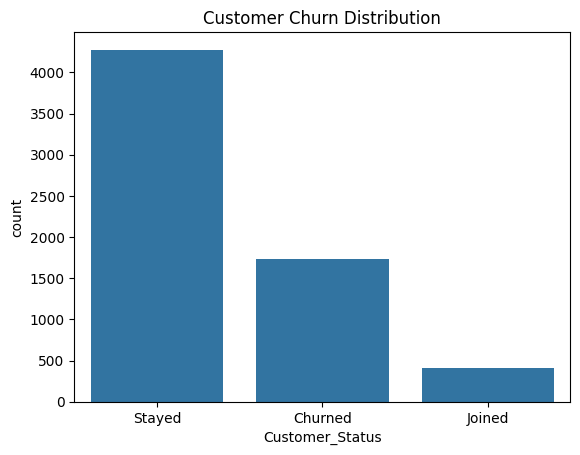

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x='Customer_Status',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

Customer Churn Distribution – Business Insights

1 - Customer retention is strong, but the sizable churned customer base represents a significant revenue leakage, making churn reduction a key business priority.

2 - The imbalance between retained and churned customers justifies developing a churn prediction model to proactively identify at-risk customers and improve retention through targeted interventions.

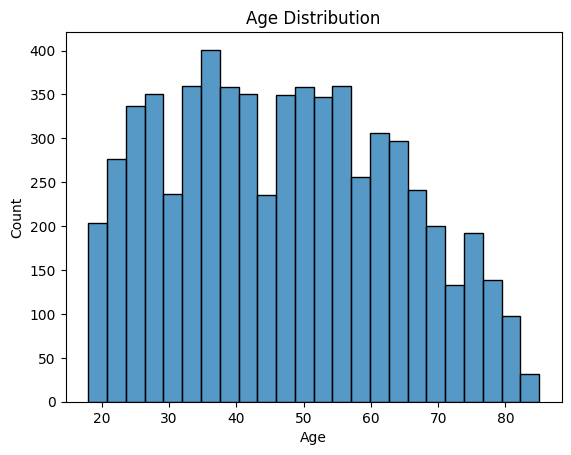

In [ ]:
sns.histplot(
    data=df,
    x='Age',
)

plt.title("Age Distribution")
plt.show()

Age Distribution – Business Insights

1 - The telecom company's customer base spans a broad age range, indicating that its services appeal to multiple demographic segments rather than a single age group.

2 - Since customers are well distributed across age groups, age alone is unlikely to explain customer behavior and should be analyzed alongside customer status (e.g., Age vs. Churn) to identify churn-prone segments.

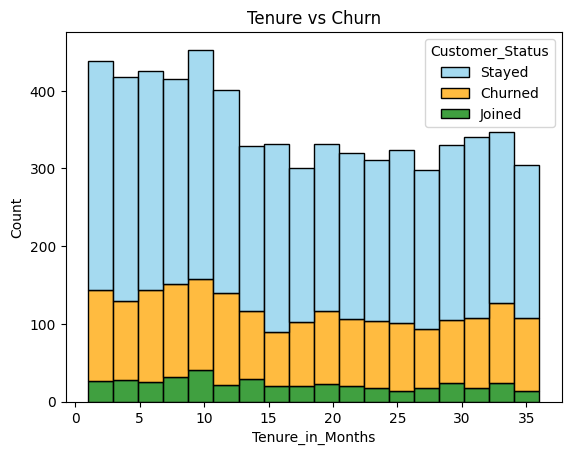

In [ ]:
sns.histplot(
    data=df,
    x='Tenure_in_Months',
    hue='Customer_Status',
    multiple='stack',   # <-- this is the fix
    palette={'Stayed': 'skyblue', 'Churned': 'orange', 'Joined': 'green'}
)
plt.title("Tenure vs Churn")
plt.ylabel("Count")
plt.show()

Tenure vs Churn – Business Insights

1 - Customers with shorter tenure exhibit a relatively higher proportion of churn, indicating that the initial months of the customer lifecycle are the most critical for retention.

2 - Strengthening onboarding, early engagement, and personalized retention campaigns during the first year could significantly reduce customer attrition and improve long-term customer loyalty.

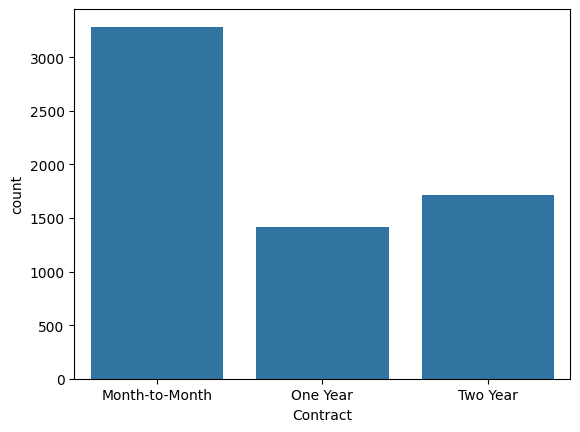

In [ ]:
sns.countplot(
    data=df,
    x='Contract',
)


plt.show()

Contract Type Distribution – Business Insights

1 - The majority of customers are on Month-to-Month contracts, indicating that a large portion of the customer base is not committed to long-term plans and may be more susceptible to switching providers.

2 - Increasing adoption of One-Year and Two-Year contracts through targeted pricing, bundled services, or loyalty incentives can improve customer retention and enhance long-term revenue stability.

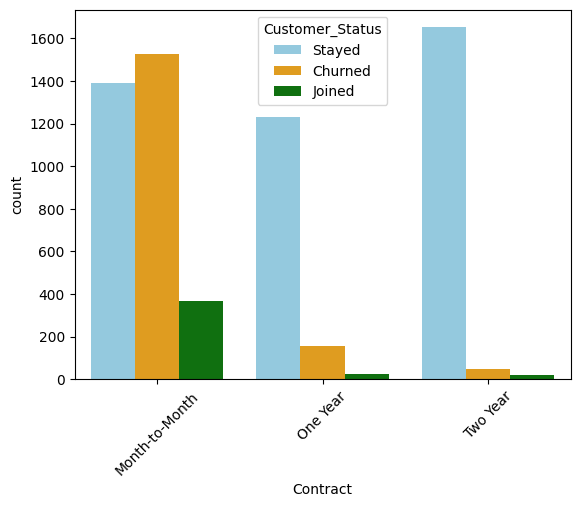

In [ ]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Customer_Status',
    palette={'Stayed': 'skyblue', 'Churned': 'orange', 'Joined': 'green'}
)

plt.xticks(rotation=45)
plt.show()

Contract Type vs Customer Status – Business Insights

1 - Customers on Month-to-Month contracts exhibit the highest churn, whereas customers with One-Year and especially Two-Year contracts have significantly better retention.

2 - Encouraging customers to transition from Month-to-Month to longer-term contracts through discounts, bundled services, or loyalty incentives could substantially reduce churn and improve customer lifetime value.

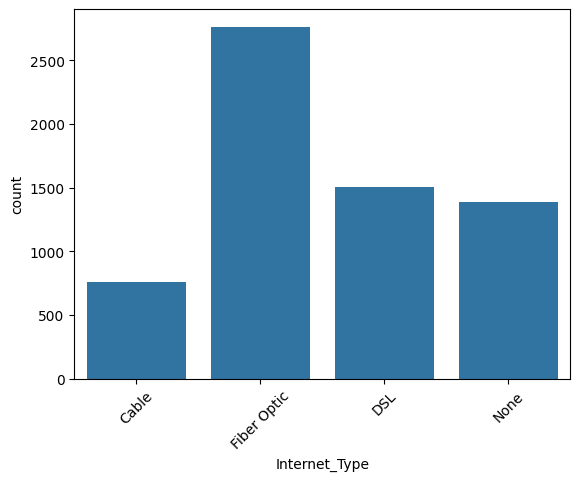

In [ ]:
sns.countplot(
    data=df,
    x='Internet_Type',
)

plt.xticks(rotation=45)
plt.show()

Internet Type Distribution – Business Insights

1 - Fiber Optic is the most widely used internet service, making it the company's primary service offering and a key driver of customer revenue.

2 - Since the customer base is spread across multiple internet technologies (Fiber Optic, DSL, and Cable), further churn analysis by internet type is essential to identify whether any specific service experiences disproportionately higher customer attrition.

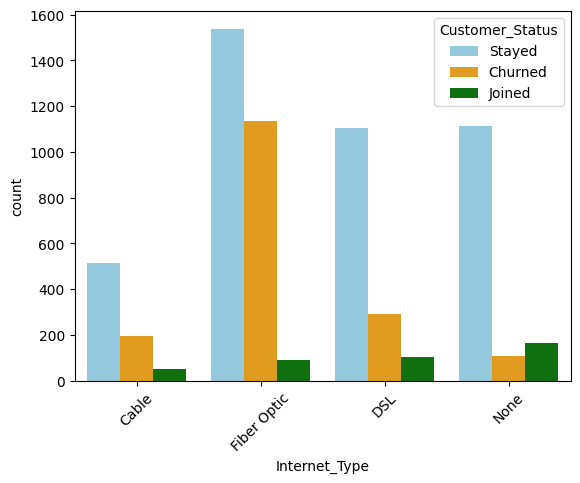

In [ ]:
sns.countplot(
    data=df,
    x='Internet_Type',
    hue='Customer_Status',
    palette={'Stayed': 'skyblue', 'Churned': 'orange', 'Joined': 'green'}
)

plt.xticks(rotation=45)
plt.show()

Internet Type vs Customer Status – Business Insights

1 - Customers using Fiber Optic services exhibit the highest churn, suggesting that this segment should be prioritized for root cause analysis to identify potential issues related to pricing, service quality, or customer experience.

2 - DSL and customers with no internet service show comparatively stronger retention, indicating that targeted retention strategies focused on Fiber Optic customers could have the greatest impact on reducing overall churn.

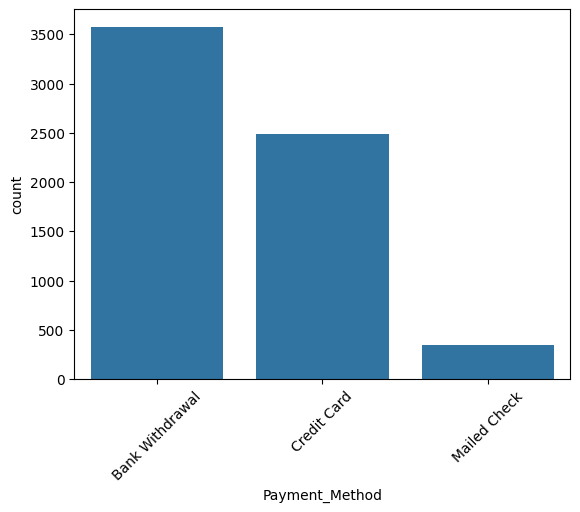

In [ ]:
sns.countplot(
    data=df,
    x='Payment_Method',
)

plt.xticks(rotation=45)
plt.show()

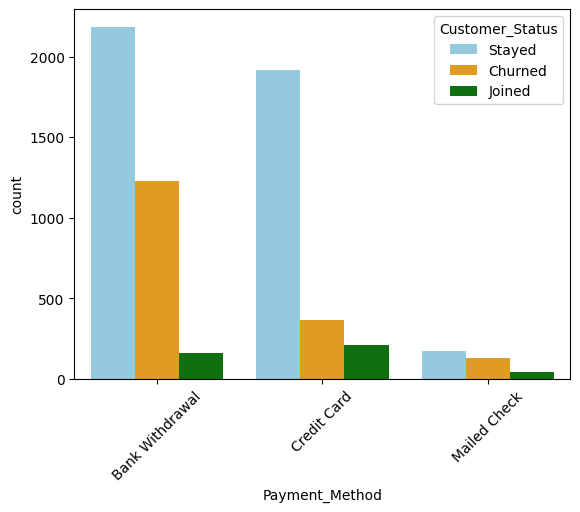

In [ ]:
sns.countplot(
    data=df,
    x='Payment_Method',
    hue='Customer_Status',
    palette={'Stayed': 'skyblue', 'Churned': 'orange', 'Joined': 'green'}
)

plt.xticks(rotation=45)
plt.show()

Payment Method vs Customer Status – Business Insights

1 - Customers using Bank Withdrawal exhibit the highest churn, indicating that this payment method is associated with greater customer attrition and should be prioritized for further investigation.

2 - Customers paying via Credit Card demonstrate significantly better retention, suggesting that encouraging digital payment methods through incentives or auto-payment options could help improve customer retention.

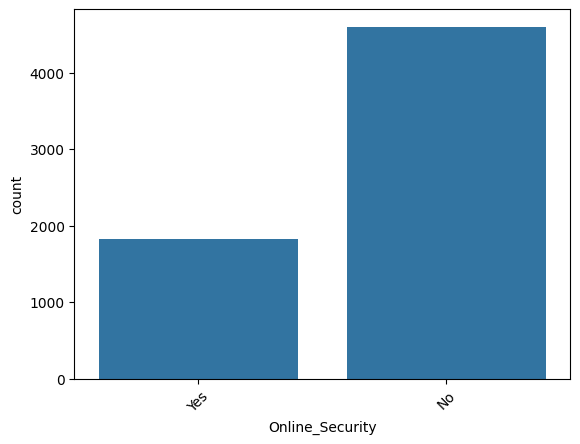

In [ ]:
sns.countplot(
    data=df,
    x='Online_Security'
)

plt.xticks(rotation=45)
plt.show()

Online Security Distribution – Business Insights

1 - A majority of customers have not subscribed to the Online Security service, indicating low adoption of this value-added feature.

2 - This presents an opportunity to increase service adoption through bundled plans or promotional offers, potentially improving customer engagement and increasing average revenue per user (ARPU).

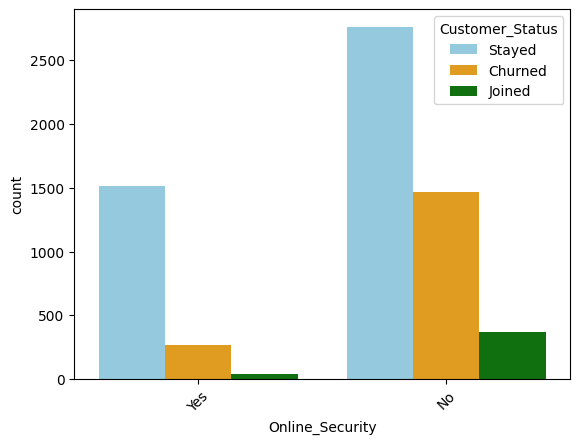

In [ ]:
sns.countplot(
    data=df,
    x='Online_Security',
    hue='Customer_Status',
    palette={'Stayed': 'skyblue', 'Churned': 'orange', 'Joined': 'green'}
)

plt.xticks(rotation=45)
plt.show()

Online Security vs Customer Status – Business Insights

1 - Customers without Online Security exhibit significantly higher churn, suggesting that the absence of this service is associated with increased customer attrition.

2 - Promoting Online Security through bundled packages or discounted upgrades could enhance customer retention while increasing adoption of value-added services.

Text(0, 0.5, 'Count')

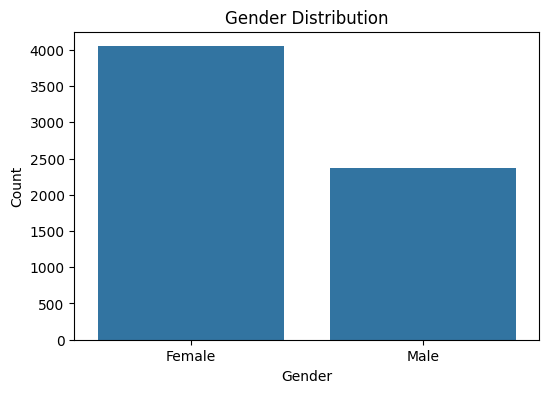

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

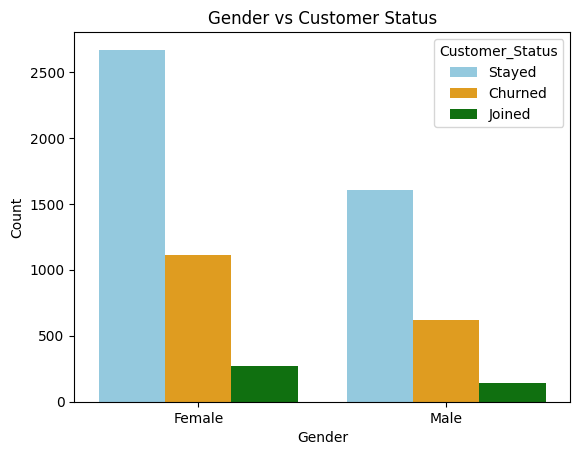

In [ ]:

sns.countplot(
    data=df,
    x='Gender',
    hue='Customer_Status',
    palette={
        'Stayed':'skyblue',
        'Churned':'orange',
        'Joined':'green'
    }
)

plt.title("Gender vs Customer Status")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Gender vs Customer Status – Business Insights

1 - Customer retention and churn patterns are broadly similar across both genders, indicating that gender is not a strong standalone driver of customer churn.

2 - Retention strategies should focus on service-related factors such as contract type, internet service, pricing, and value-added features rather than gender-based segmentation

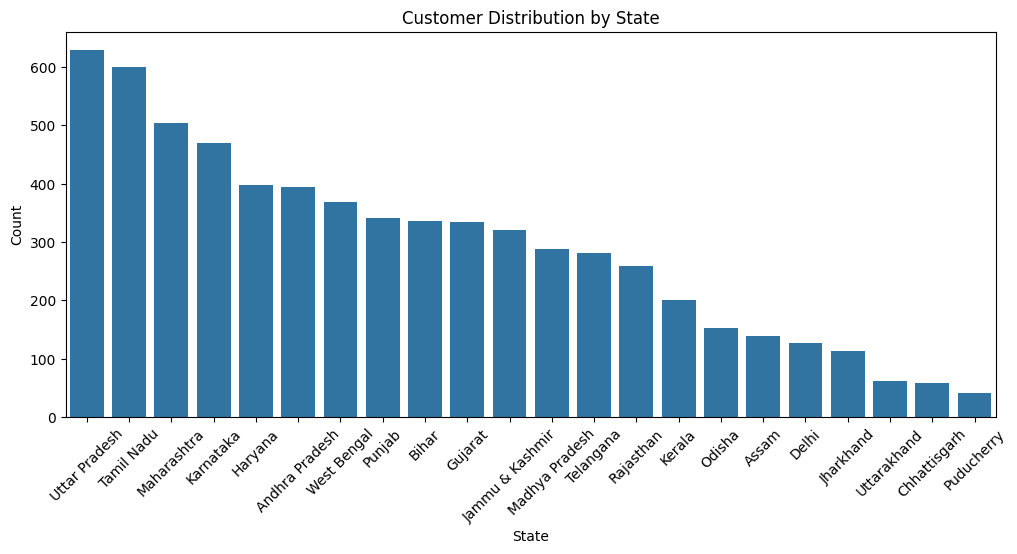

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='State',
    order=df['State'].value_counts().index
)

plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Customer Distribution by State – Business Insights

1 - The customer base is concentrated in a few states, particularly Uttar Pradesh, Tamil Nadu, Maharashtra, and Karnataka, making these regions key contributors to the company's revenue.

2 - States with a larger customer base should be prioritized for customer experience improvements and retention initiatives, as even small reductions in churn can have a significant business impact.

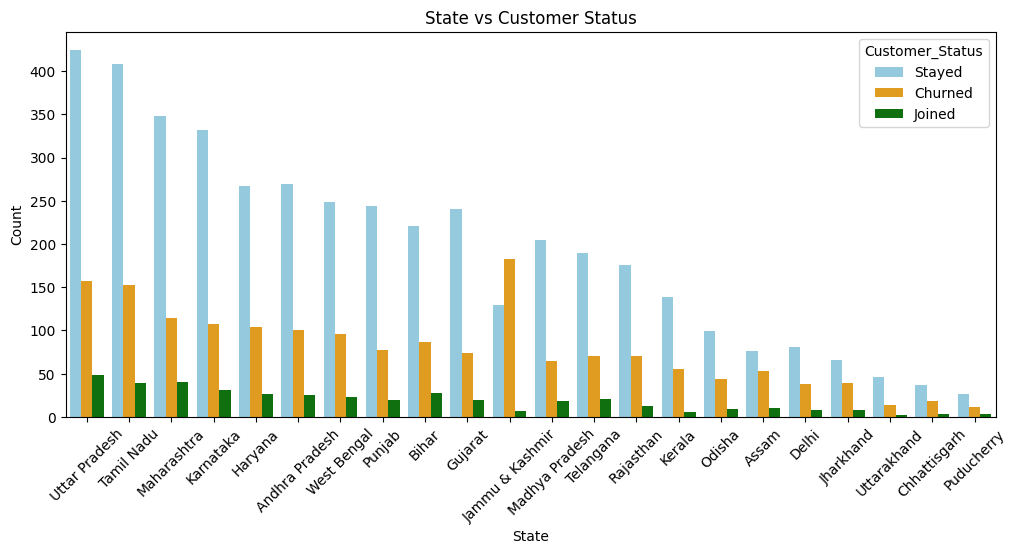

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='State',
    hue='Customer_Status',
    order=df['State'].value_counts().index,
    palette={
        'Stayed':'skyblue',
        'Churned':'orange',
        'Joined':'green'
    }
)

plt.title("State vs Customer Status")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

State vs Customer Status – Business Insights

1 - Jammu & Kashmir stands out with churn exceeding retained customers, indicating a potential regional issue that requires immediate investigation into factors such as network quality, pricing, or service availability.

2 - Most other states exhibit stronger customer retention than churn, suggesting that targeted, state-specific retention strategies—rather than a uniform nationwide approach—would be more effective in reducing customer attrition.

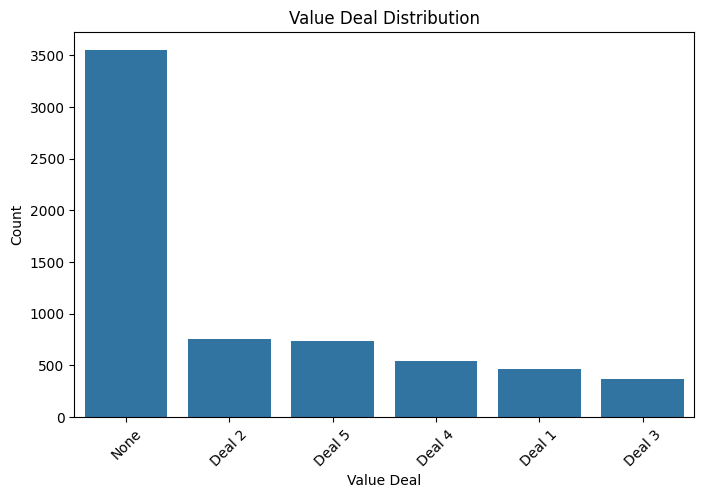

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Value_Deal',
    order=df['Value_Deal'].value_counts().index,
)

plt.title("Value Deal Distribution")
plt.xlabel("Value Deal")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

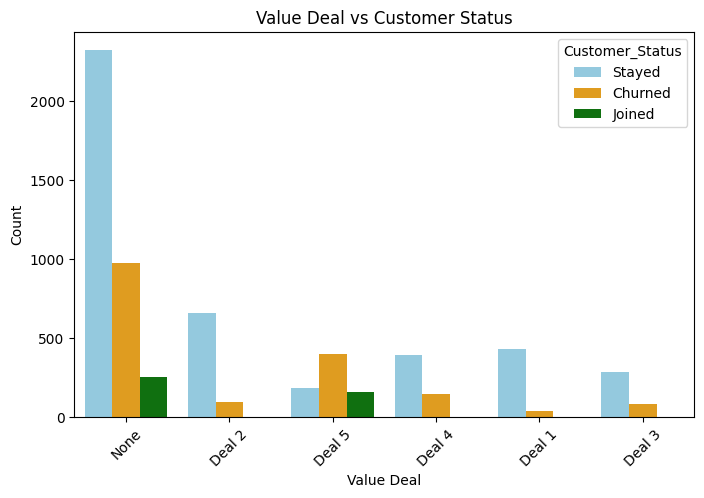

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Value_Deal',
    hue='Customer_Status',
    order=df['Value_Deal'].value_counts().index,
    palette={
        'Stayed':'skyblue',
        'Churned':'orange',
        'Joined':'green'
    }
)

plt.title("Value Deal vs Customer Status")
plt.xlabel("Value Deal")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Value Deal vs Customer Status – Business Insights

1 - Deal 5 stands out with churned customers significantly exceeding retained customers, indicating a critical flaw with this specific offer that requires immediate investigation into factors such as pricing, perceived value, or service quality.

2 - Deals 1 and 2 exhibit remarkably strong customer retention, suggesting that actively migrating the massive, vulnerable base of customers currently without any deal ("None") onto these high-performing plans would effectively reduce overall attrition.

C:\Users\anujj\AppData\Local\Temp\ipykernel_29536\429414220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


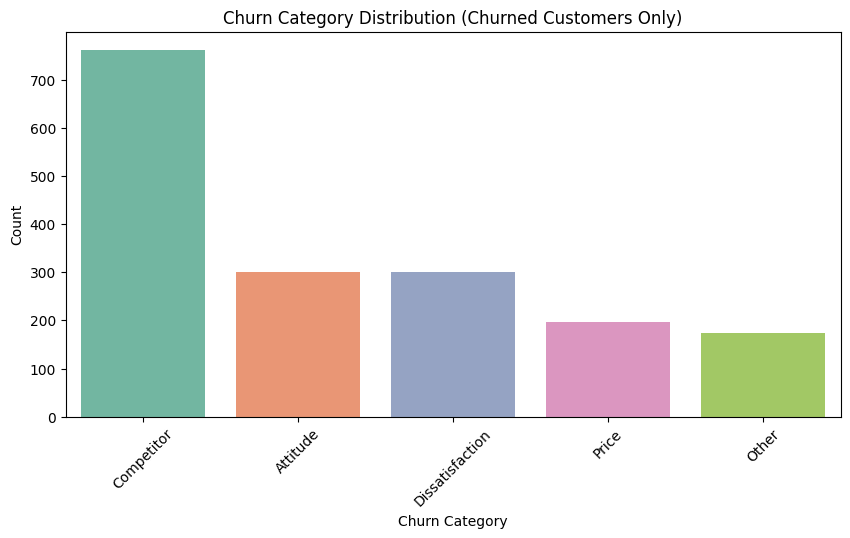

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df[df['Customer_Status'] == 'Churned'],
    x='Churn_Category',
    order=df[df['Customer_Status'] == 'Churned']['Churn_Category'].value_counts().index,
    palette='Set2'
)

plt.title("Churn Category Distribution (Churned Customers Only)")
plt.xlabel("Churn Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Churn Category Distribution – Business Insights

1 - "Competitor" influence is by far the dominant driver of churn, exceeding 700 lost customers, indicating that rivals are currently offering a more compelling value proposition and highlighting an urgent need for a competitive market analysis to close the gap.

2 - "Attitude" and "Dissatisfaction" combined account for a massive share of attrition that significantly outranks "Price," suggesting that investing in customer service training and resolving internal support bottlenecks will yield higher retention than simply cutting costs.

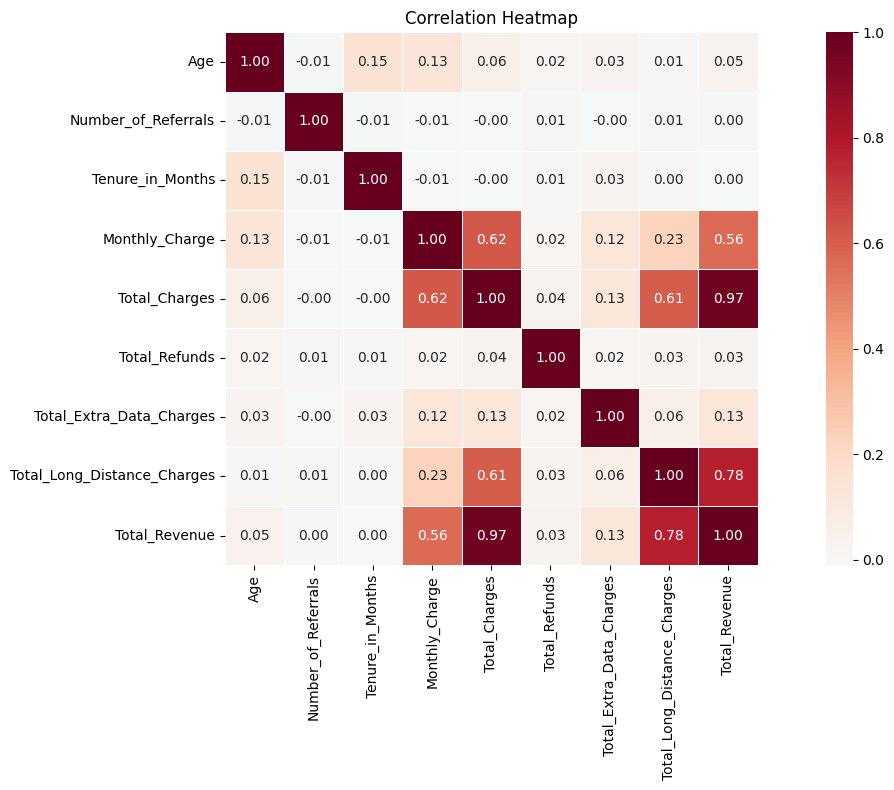

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

Correlation Heatmap – Business Insights

1 - The strong positive correlation (0.78) between Total_Long_Distance_Charges and Total_Revenue highlights that long-distance usage is a major secondary driver of overall customer value, suggesting the company should prioritize marketing long-distance add-ons or bundling them into premium tiers to maximize profitability.

2 - Number_of_Referrals exhibits a near-zero correlation with both Total_Revenue (0.00) and Tenure_in_Months (-0.01), revealing that the current referral program is ineffective at acquiring high-value or long-lasting customers and needs to be restructured to incentivize lead quality over sheer quantity.

C:\Users\anujj\AppData\Local\Temp\ipykernel_29536\3730962053.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Customer_Status', ylabel='Monthly_Charge'>

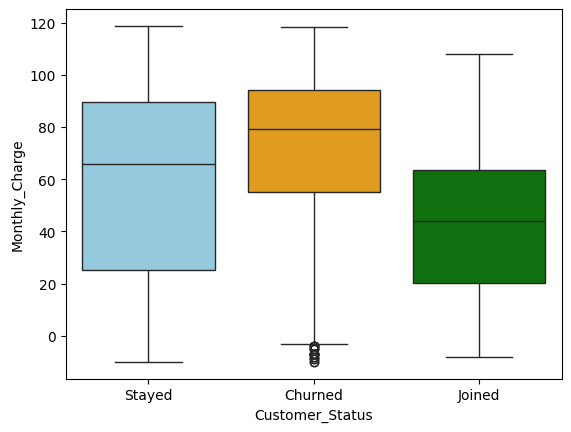

In [ ]:
sns.boxplot(
    data=df,
    x='Customer_Status',
    y='Monthly_Charge',
    palette={
            'Stayed':'skyblue',
            'Churned':'orange',
            'Joined':'green'
        }
    
)

Monthly Charge vs Customer Status – Business Insights

1 - Churned customers exhibit a significantly higher median monthly charge (approximately 80) compared to those who stayed (approximately 65), indicating that price sensitivity or a lack of perceived value at premium tiers is a major driver of attrition, requiring targeted retention discounts or value-adds for high-paying subscribers.

2 - Newly acquired customers ("Joined") are predominantly entering at lower price brackets (median around 45), suggesting that while budget-friendly pricing successfully drives initial acquisition, the company must develop a careful, gradual upselling strategy to increase revenue without triggering the price-related churn observed at higher tiers.

C:\Users\anujj\AppData\Local\Temp\ipykernel_29536\2005776778.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Customer_Status', ylabel='Tenure_in_Months'>

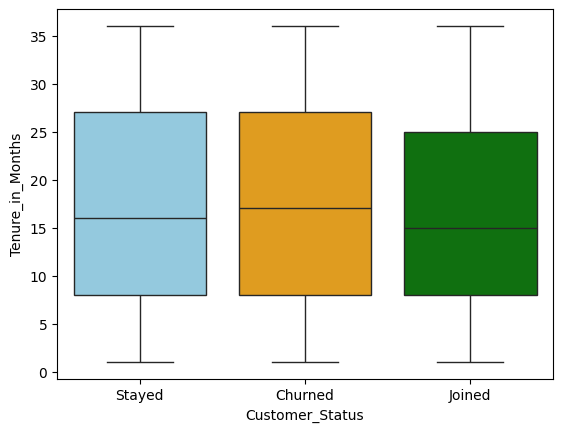

In [ ]:
sns.boxplot(
    data=df,
    x='Customer_Status',
    y='Tenure_in_Months',
    palette={
                'Stayed':'skyblue',
                'Churned':'orange',
                'Joined':'green'
            }
)

C:\Users\anujj\AppData\Local\Temp\ipykernel_29536\487824692.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Customer_Status', ylabel='Total_Charges'>

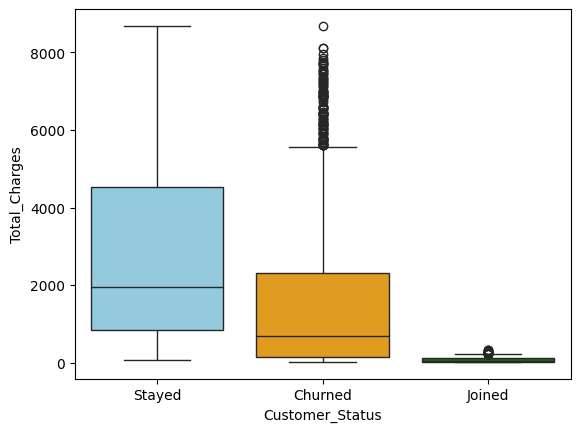

In [ ]:
sns.boxplot(
    data=df,
    x='Customer_Status',
    y='Total_Charges',
    palette={
            'Stayed':'skyblue',
            'Churned':'orange',
            'Joined':'green'
        }
)

Total Charges vs Customer Status – Business Insights

1 - Retained customers exhibit significantly higher total accumulated charges than churned customers, indicating that improving retention in the early stages can increase customer lifetime value and long-term revenue.

2 - The presence of high-value churned customers with substantial total charges highlights the need for targeted retention programs and proactive engagement for high-value accounts to minimize revenue loss.